# CS3807 — Deep Learning Laboratory — Experiment 5
### Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation

**Model:** MobileNetV2 (ImageNet-pretrained backbone, frozen for Sections 5–9)
**Dataset:** Oxford-IIIT Pet (37 breeds), downloaded directly from robots.ox.ac.uk — no Kaggle auth, no `tensorflow_datasets`
**Seed:** 109 (fixed across `random`, `numpy`, `tensorflow`)

**Runtime shape (Colab free T4, approximate):**
| Phase | Time |
|---|---|
| Setup + feature precompute | 5–10 min |
| Sweep: init / regularization / BN / optimizers / hyperparameters | 30–60 min |
| Transfer learning vs fine-tuning (Sec. 10) | 20–30 min |
| 5-fold CV (3 frozen configs + 1 fine-tuned config) | 45–90 min — **the fine-tuned fold loop is the slow part** |
| Final retrain + test evaluation | 15–25 min |

## 0. Setup: imports, seeding, plot styling

In [1]:
# tensorflow_datasets removed entirely (see cell below) -- Oxford-IIIT Pet is downloaded
# directly from its original host instead. This sidesteps the tensorflow_datasets /
# tensorflow_metadata / protobuf gencode-vs-runtime conflict entirely: nothing in that
# dependency chain is imported anywhere in this notebook anymore.
print("No extra installs needed -- dataset is fetched directly in the next cell.")


No extra installs needed -- dataset is fetched directly in the next cell.


In [2]:
import os, time, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

SEED = 109  # fixed identifier seed — keep this unchanged

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed()

IMG_SIZE = 224
PLOT_DIR = "/content/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Font style required for report figures: 13-15 pt, bold axis labels/titles
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.dpi": 120,
})

def save_and_show(fig, name):
    path = os.path.join(PLOT_DIR, f"{name}.png")
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

## 1. Dataset: Oxford-IIIT Pet (downloaded directly from source, no `tensorflow_datasets`)

In [3]:
DATA_DIR = "/content/oxford_pets"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
ANNOT_DIR = os.path.join(DATA_DIR, "annotations")
os.makedirs(DATA_DIR, exist_ok=True)

import urllib.request, tarfile

def download_and_extract(url, dest_dir):
    fname = os.path.join(dest_dir, os.path.basename(url))
    if not os.path.exists(fname):
        print(f"Downloading {url} ...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already downloaded: {fname}")
    print(f"Extracting {fname} ...")
    with tarfile.open(fname) as tar:
        # filter="data" (Python 3.12+) rejects any archive entry that would write
        # outside dest_dir (path traversal, CVE-2007-4559) -- cheap insurance
        # regardless of how trustworthy the source is.
        tar.extractall(dest_dir, filter="data")

print("Fetching Oxford-IIIT Pet directly from the source host (first run ~3-5 min for ~800MB)...")
download_and_extract("https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz", DATA_DIR)
download_and_extract("https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz", DATA_DIR)

def parse_list_file(path):
    """Each non-comment line: <image_id> <class_id 1-37> <species 1/2> <breed_id>"""
    entries = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            image_id = parts[0]
            class_id = int(parts[1]) - 1  # zero-index for Keras
            entries.append((image_id, class_id))
    return entries

trainval_entries = parse_list_file(os.path.join(ANNOT_DIR, "trainval.txt"))
test_entries = parse_list_file(os.path.join(ANNOT_DIR, "test.txt"))

def entries_to_paths(entries):
    paths = [os.path.join(IMAGES_DIR, f"{img_id}.jpg") for img_id, _ in entries]
    labels = [lbl for _, lbl in entries]
    return paths, labels

train_paths_all, train_labels_all = entries_to_paths(trainval_entries)
test_paths, test_labels = entries_to_paths(test_entries)

NUM_CLASSES = len(set(train_labels_all + test_labels))

# Breed names come from the filename convention "<Breed>_<number>.jpg" -- there's no
# separate names file, so we derive them once from any file of each class.
class_names = {}
for img_id, lbl in trainval_entries + test_entries:
    if lbl not in class_names:
        class_names[lbl] = "_".join(img_id.split("_")[:-1])
label_names = [class_names[i] for i in range(NUM_CLASSES)]

print(f"Classes (breeds): {NUM_CLASSES}")
print(f"Trainval pool: {len(train_paths_all)} | Test: {len(test_paths)}")

# 80/20 split of the trainval pool into train/val, seeded for reproducibility
rng = np.random.RandomState(SEED)
idx = rng.permutation(len(train_paths_all))
n_val = int(0.2 * len(idx))
val_idx, train_idx = idx[:n_val], idx[n_val:]

train_paths  = [train_paths_all[i] for i in train_idx]
train_labels = [train_labels_all[i] for i in train_idx]
val_paths    = [train_paths_all[i] for i in val_idx]
val_labels   = [train_labels_all[i] for i in val_idx]

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

def load_and_preprocess(path, label):
    img_bytes = tf.io.read_file(path)
    # decode_image (not decode_jpeg) -- a handful of files in this dataset are actually
    # PNG/other formats despite the .jpg extension; this handles them without erroring.
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, label

def make_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

ds_train = make_dataset(train_paths, train_labels)
ds_val   = make_dataset(val_paths, val_labels)
ds_test  = make_dataset(test_paths, test_labels)


CACHE_DIR = "/content/tfcache"
os.makedirs(CACHE_DIR, exist_ok=True)

def cached_dataset(paths, labels, cache_name, batch_size=32, shuffle=False):
    """Builds a dataset that decodes each image once and caches the result to disk --
    every epoch after the first reads cached tensors instead of re-decoding JPEGs.
    Caches to disk (not memory) specifically so repeated epochs don\'t risk the OOM
    that an in-memory cache or a materialized numpy array would."""
    ds = make_dataset(paths, labels)
    ds = ds.cache(os.path.join(CACHE_DIR, cache_name))
    if shuffle:
        ds = ds.shuffle(1024, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def clear_cache(cache_name):
    """Deletes a cache's on-disk files -- call after a fold/run is done so the
    cache directory doesn\'t grow unbounded across CV folds."""
    import glob
    for f in glob.glob(os.path.join(CACHE_DIR, cache_name) + "*"):
        os.remove(f)


Fetching Oxford-IIIT Pet directly from the source host (first run ~3-5 min for ~800MB)...
Extracting /content/oxford_pets/images.tar.gz ...
Extracting /content/oxford_pets/annotations.tar.gz ...
Classes (breeds): 37
Trainval pool: 3680 | Test: 3669
Train: 2944 | Val: 736 | Test: 3669


## 2. Frozen MobileNetV2 backbone: precompute bottleneck features


In [4]:
print("Building frozen MobileNetV2 base (ImageNet weights)...")
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False,
                          weights="imagenet", pooling="avg")
base_model.trainable = False

def extract_features(dataset, batch_size=64):
    feats, labels = [], []
    for imgs, lbls in dataset.batch(batch_size):
        f = base_model(imgs, training=False)
        feats.append(f.numpy())
        labels.append(lbls.numpy())
    return np.concatenate(feats), np.concatenate(labels)

t0 = time.time()
X_train, y_train = extract_features(ds_train)
X_val, y_val     = extract_features(ds_val)
X_test, y_test   = extract_features(ds_test)
print(f"Feature extraction done in {time.time()-t0:.1f}s")
print(f"Shapes -> train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")

np.savez("/content/cached_features.npz",
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test)
print("Cached to /content/cached_features.npz (survives if you re-run later cells without redoing this).")

Building frozen MobileNetV2 base (ImageNet weights)...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature extraction done in 37.2s
Shapes -> train: (2944, 1280), val: (736, 1280), test: (3669, 1280)
Cached to /content/cached_features.npz (survives if you re-run later cells without redoing this).


## 3. Reusable head-builder, optimizer factory, and training function

In [5]:
INIT_MAP = {
    "zero":   "zeros",
    "random": tf.keras.initializers.RandomNormal(stddev=0.05, seed=SEED),
    "xavier": tf.keras.initializers.GlorotUniform(seed=SEED),
    "he":     tf.keras.initializers.HeNormal(seed=SEED),
}

def build_head(init_name="he", dropout_rate=0.25, use_bn=False, l2_lambda=0.0,
               num_classes=None, input_dim=1280):
    num_classes = num_classes or NUM_CLASSES
    kernel_init = INIT_MAP.get(init_name, init_name)
    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    model = models.Sequential(name=f"head_{init_name}")
    model.add(layers.Input(shape=(input_dim,)))
    model.add(layers.Dense(256, kernel_initializer=kernel_init, kernel_regularizer=reg))
    if use_bn:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax", kernel_initializer=kernel_init))
    return model

def get_optimizer(name="adam", lr=0.001):
    name = name.lower()
    if name == "sgd":       return optimizers.SGD(learning_rate=lr)
    if name == "momentum":  return optimizers.SGD(learning_rate=lr, momentum=0.9)
    if name == "rmsprop":   return optimizers.RMSprop(learning_rate=lr)
    if name == "adam":      return optimizers.Adam(learning_rate=lr)
    raise ValueError(f"Unknown optimizer: {name}")

def train_head(init_name="he", dropout_rate=0.25, use_bn=False, l2_lambda=0.0,
               optimizer_name="adam", lr=0.001, batch_size=32, epochs=25, verbose=0):
    set_seed()
    model = build_head(init_name, dropout_rate, use_bn, l2_lambda)
    model.compile(optimizer=get_optimizer(optimizer_name, lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                      epochs=epochs, batch_size=batch_size, verbose=verbose)
    elapsed = time.time() - t0
    return model, hist, elapsed

## 4. Section 5 — Weight Initialization (Plots 1 & 2)

In [6]:
print("Running weight-initialization sweep (zero / random / xavier / he)...")
init_histories, init_times = {}, {}
for name in ["zero", "random", "xavier", "he"]:
    _, hist, t = train_head(init_name=name, dropout_rate=0.0, use_bn=False, epochs=25)
    init_histories[name] = hist
    init_times[name] = t
    print(f"  {name:8s} | final train_loss={hist.history['loss'][-1]:.4f} | "
          f"final val_acc={hist.history['val_accuracy'][-1]*100:.2f}% | time={t:.1f}s")

Running weight-initialization sweep (zero / random / xavier / he)...
  zero     | final train_loss=3.6109 | final val_acc=2.17% | time=12.6s
  random   | final train_loss=0.0008 | final val_acc=91.85% | time=11.2s
  xavier   | final train_loss=0.0006 | final val_acc=92.12% | time=11.5s
  he       | final train_loss=0.0007 | final val_acc=92.80% | time=11.4s


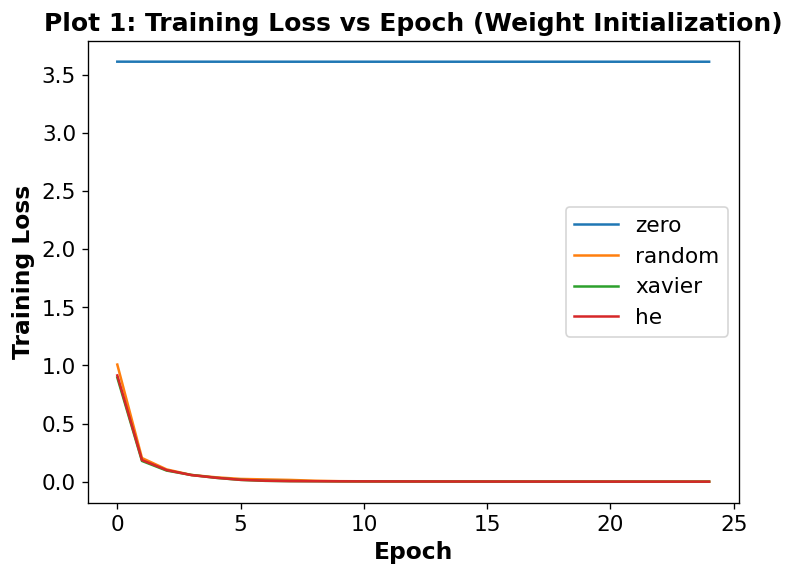

Saved: /content/plots/plot1_init_training_loss.png


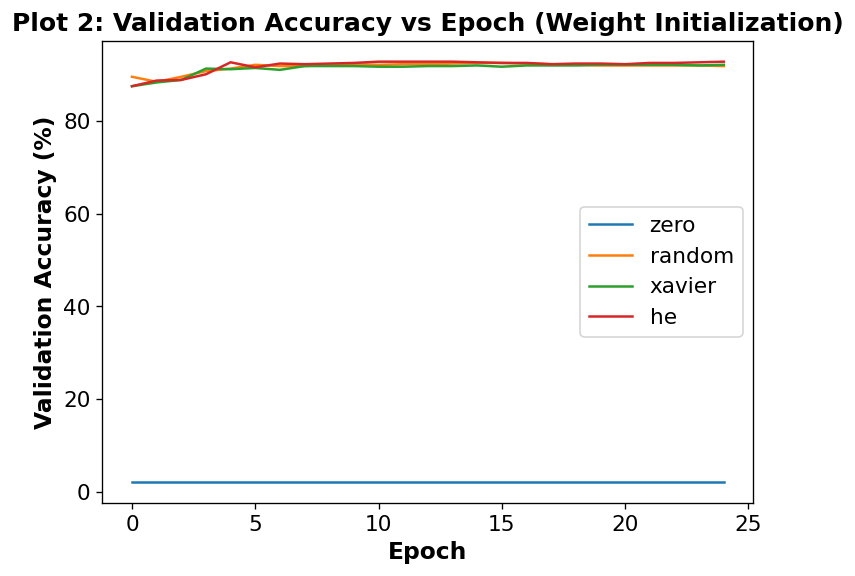

Saved: /content/plots/plot2_init_val_accuracy.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, hist in init_histories.items():
    ax.plot(hist.history["loss"], label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss")
ax.set_title("Plot 1: Training Loss vs Epoch (Weight Initialization)")
ax.legend()
save_and_show(fig, "plot1_init_training_loss")

fig, ax = plt.subplots(figsize=(7, 5))
for name, hist in init_histories.items():
    ax.plot([v * 100 for v in hist.history["val_accuracy"]], label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 2: Validation Accuracy vs Epoch (Weight Initialization)")
ax.legend()
save_and_show(fig, "plot2_init_val_accuracy")

## 5. Section 6 — Regularization and Overfitting (Plots 3 & 4)


In [8]:
reg_configs = {
    "no_reg":  dict(dropout_rate=0.0, use_bn=False, l2_lambda=0.0),
    "l2":      dict(dropout_rate=0.0, use_bn=False, l2_lambda=0.001),
    "dropout": dict(dropout_rate=0.5, use_bn=False, l2_lambda=0.0),
    "batchnorm": dict(dropout_rate=0.0, use_bn=True, l2_lambda=0.0),
}

reg_histories = {}
for name, cfg in reg_configs.items():
    _, hist, t = train_head(init_name="he", optimizer_name="adam", epochs=30, **cfg)
    reg_histories[name] = hist
    gap = hist.history["accuracy"][-1] - hist.history["val_accuracy"][-1]
    print(f"  {name:10s} | train_acc={hist.history['accuracy'][-1]*100:.2f}% | "
          f"val_acc={hist.history['val_accuracy'][-1]*100:.2f}% | gap={gap*100:.2f} pts | time={t:.1f}s")

  no_reg     | train_acc=100.00% | val_acc=92.80% | gap=7.20 pts | time=13.4s
  l2         | train_acc=100.00% | val_acc=91.98% | gap=8.02 pts | time=13.9s
  dropout    | train_acc=98.44% | val_acc=90.90% | gap=7.54 pts | time=14.0s
  batchnorm  | train_acc=100.00% | val_acc=91.98% | gap=8.02 pts | time=14.4s


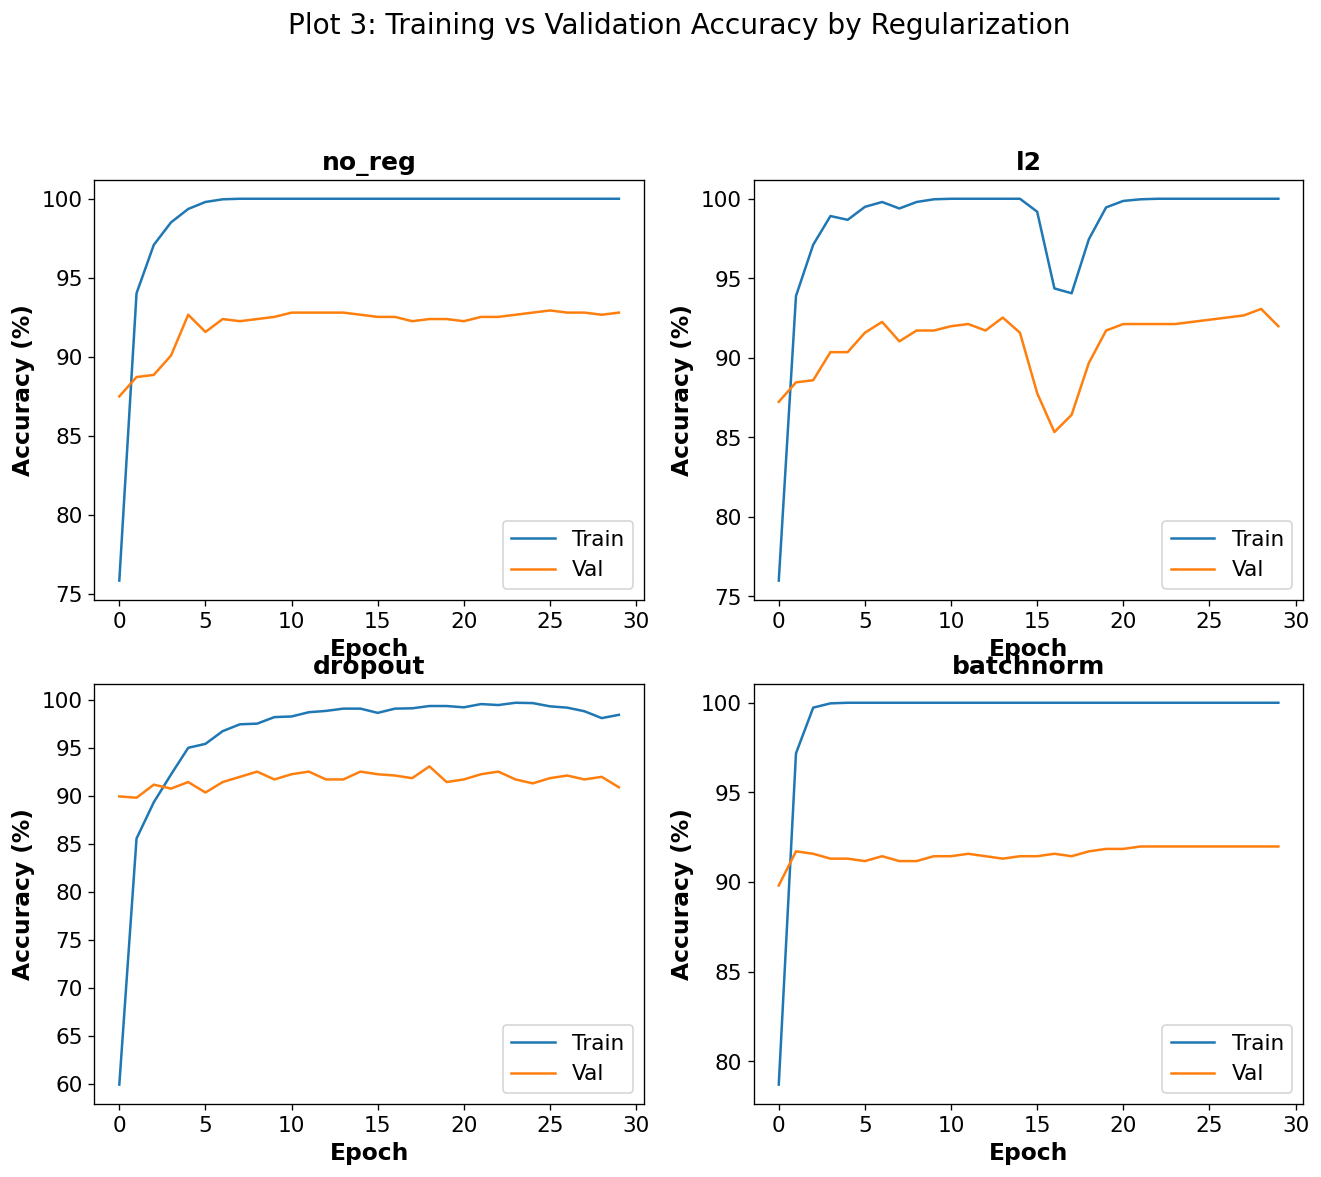

Saved: /content/plots/plot3_regularization_accuracy.png


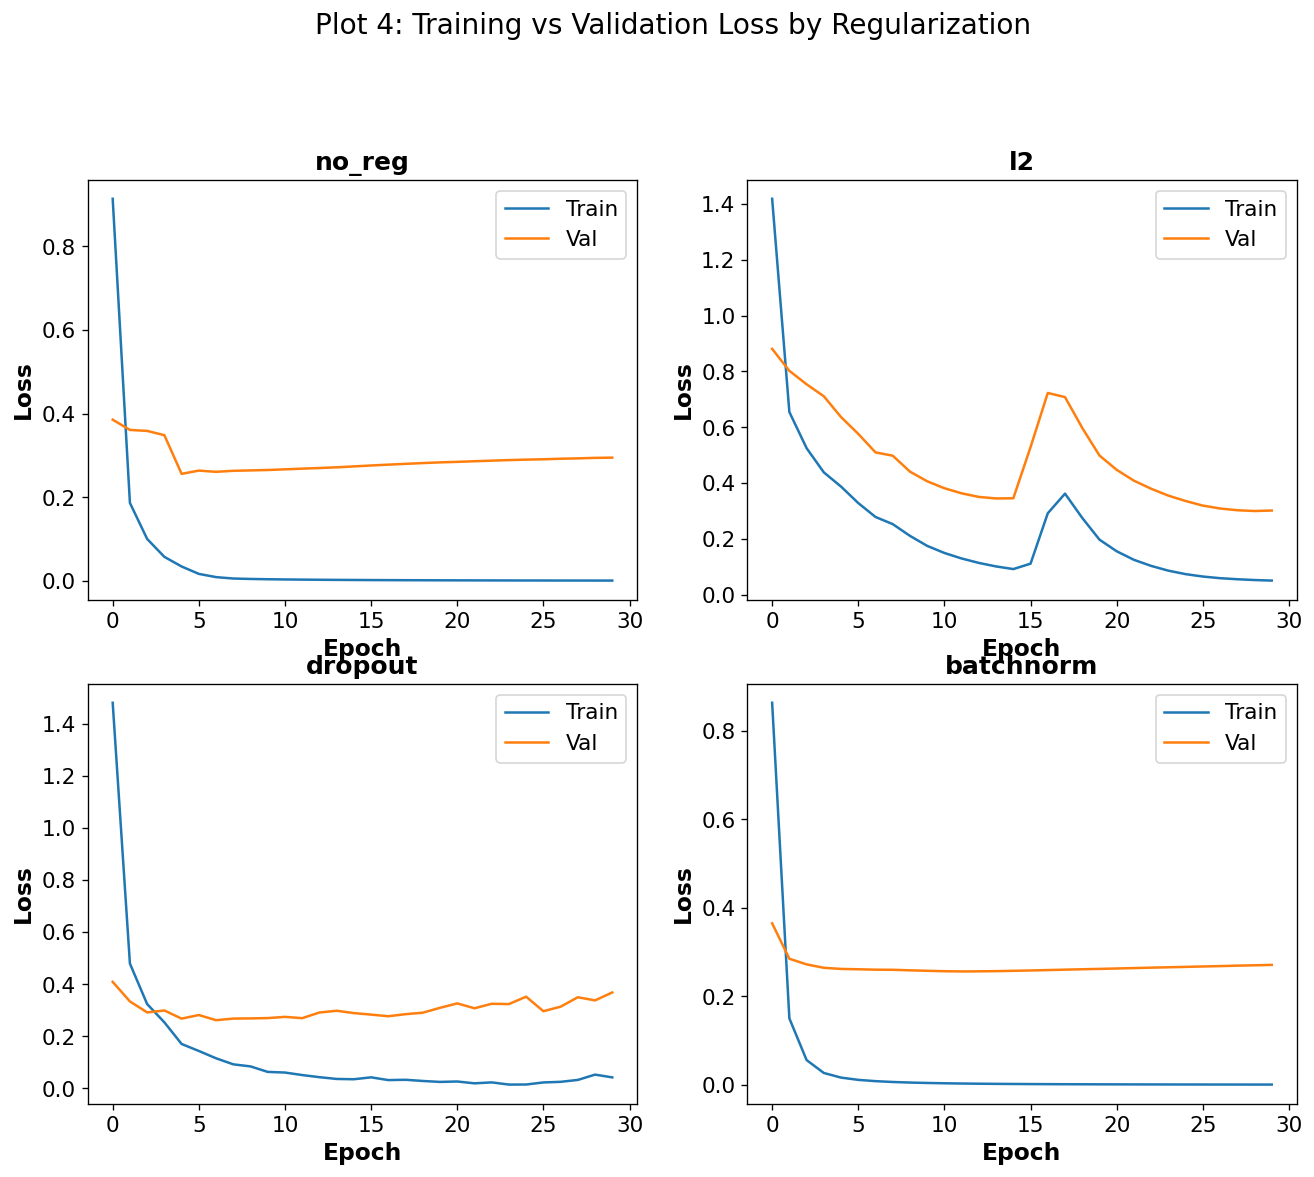

Saved: /content/plots/plot4_regularization_loss.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (name, hist) in zip(axes.flat, reg_histories.items()):
    ax.plot([v*100 for v in hist.history["accuracy"]], label="Train")
    ax.plot([v*100 for v in hist.history["val_accuracy"]], label="Val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_title(name); ax.legend()
fig.suptitle("Plot 3: Training vs Validation Accuracy by Regularization", y=1.02)
save_and_show(fig, "plot3_regularization_accuracy")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (name, hist) in zip(axes.flat, reg_histories.items()):
    ax.plot(hist.history["loss"], label="Train")
    ax.plot(hist.history["val_loss"], label="Val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(name); ax.legend()
fig.suptitle("Plot 4: Training vs Validation Loss by Regularization", y=1.02)
save_and_show(fig, "plot4_regularization_loss")

## 6. Section 7 — Batch Normalization: numerical example + Plot 5

In [10]:
# Worked numerical example, matches the lab manual's illustration
x = np.array([2., 4., 6., 8.])
mu = x.mean()
var = x.var()
x_hat = (x - mu) / np.sqrt(var + 1e-8)
print(f"x = {x}")
print(f"mean (mu_B) = {mu}")
print(f"variance (sigma_B^2) = {var}")
print(f"normalized x_hat = {np.round(x_hat, 3)}")

x = [2. 4. 6. 8.]
mean (mu_B) = 5.0
variance (sigma_B^2) = 5.0
normalized x_hat = [-1.342 -0.447  0.447  1.342]


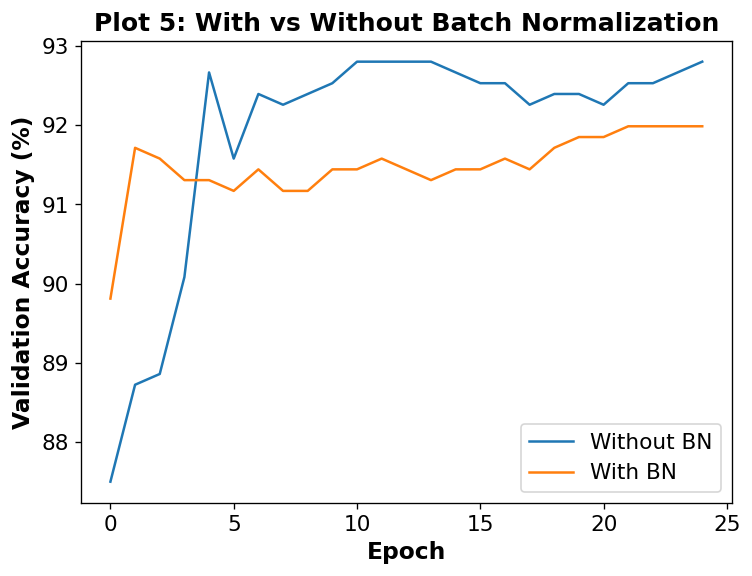

Saved: /content/plots/plot5_batchnorm_comparison.png


In [11]:
_, hist_no_bn, t1 = train_head(init_name="he", dropout_rate=0.0, use_bn=False, epochs=25)
_, hist_bn,    t2 = train_head(init_name="he", dropout_rate=0.0, use_bn=True,  epochs=25)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([v*100 for v in hist_no_bn.history["val_accuracy"]], label="Without BN")
ax.plot([v*100 for v in hist_bn.history["val_accuracy"]], label="With BN")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 5: With vs Without Batch Normalization")
ax.legend()
save_and_show(fig, "plot5_batchnorm_comparison")

## 7. Section 8 — Optimizer Comparison (Plots 6 & 7 + summary table)

In [12]:
opt_histories, opt_times = {}, {}
for opt_name in ["sgd", "momentum", "rmsprop", "adam"]:
    _, hist, t = train_head(init_name="he", dropout_rate=0.25, use_bn=True,
                             optimizer_name=opt_name, lr=0.001, epochs=25)
    opt_histories[opt_name] = hist
    opt_times[opt_name] = t
    print(f"  {opt_name:8s} | final_loss={hist.history['loss'][-1]:.4f} | "
          f"best_val_acc={max(hist.history['val_accuracy'])*100:.2f}% | time={t:.1f}s")

  sgd      | final_loss=0.8323 | best_val_acc=84.24% | time=12.2s
  momentum | final_loss=0.1196 | best_val_acc=91.85% | time=12.3s
  rmsprop  | final_loss=0.0002 | best_val_acc=92.93% | time=12.4s
  adam     | final_loss=0.0013 | best_val_acc=92.12% | time=12.7s


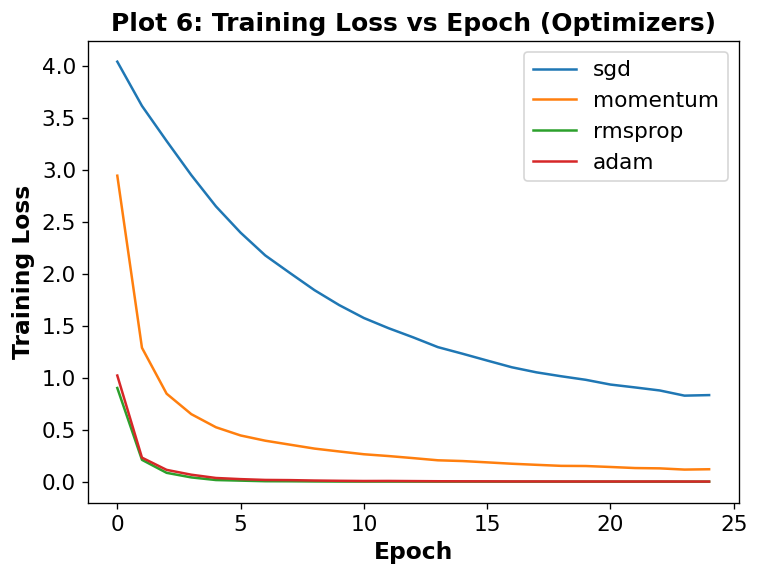

Saved: /content/plots/plot6_optimizer_loss.png


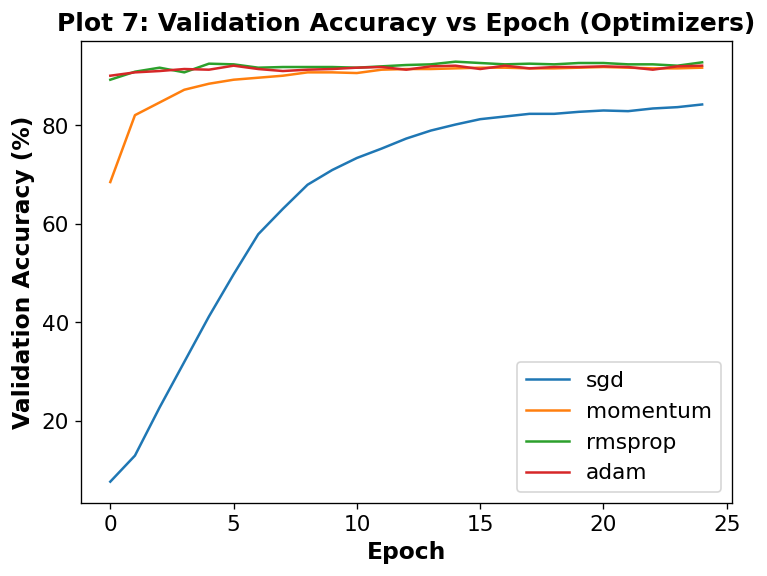

Saved: /content/plots/plot7_optimizer_val_accuracy.png


,Optimizer,Final Loss,Best Val. Accuracy,Epoch to Converge,Time (s)
0,sgd,0.8323,84.24%,25,12.2
1,momentum,0.1196,91.85%,21,12.3
2,rmsprop,0.0002,92.93%,15,12.4
3,adam,0.0013,92.12%,6,12.7


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, hist in opt_histories.items():
    ax.plot(hist.history["loss"], label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss")
ax.set_title("Plot 6: Training Loss vs Epoch (Optimizers)")
ax.legend()
save_and_show(fig, "plot6_optimizer_loss")

fig, ax = plt.subplots(figsize=(7, 5))
for name, hist in opt_histories.items():
    ax.plot([v*100 for v in hist.history["val_accuracy"]], label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 7: Validation Accuracy vs Epoch (Optimizers)")
ax.legend()
save_and_show(fig, "plot7_optimizer_val_accuracy")

rows = []
for name, hist in opt_histories.items():
    best_acc = max(hist.history["val_accuracy"])
    epoch_to_converge = int(np.argmax(hist.history["val_accuracy"])) + 1
    rows.append({
        "Optimizer": name,
        "Final Loss": round(hist.history["loss"][-1], 4),
        "Best Val. Accuracy": f"{best_acc*100:.2f}%",
        "Epoch to Converge": epoch_to_converge,
        "Time (s)": round(opt_times[name], 1),
    })
opt_table = pd.DataFrame(rows)
opt_table

## 8. Section 9 — Hyperparameter Tuning (Plots 8, 9, 10)

In [14]:
lr_results = {}
for lr in [0.001, 0.0001]:
    _, hist, _ = train_head(init_name="he", dropout_rate=0.25, use_bn=True,
                             optimizer_name="adam", lr=lr, batch_size=32, epochs=25)
    lr_results[lr] = max(hist.history["val_accuracy"]) * 100
    print(f"  lr={lr}: best val_acc={lr_results[lr]:.2f}%")

batch_results = {}
for bs in [16, 32, 64]:
    _, hist, _ = train_head(init_name="he", dropout_rate=0.25, use_bn=True,
                             optimizer_name="adam", lr=0.001, batch_size=bs, epochs=25)
    batch_results[bs] = max(hist.history["val_accuracy"]) * 100
    print(f"  batch_size={bs}: best val_acc={batch_results[bs]:.2f}%")

dropout_results = {}
for dr in [0.0, 0.25, 0.5]:
    _, hist, _ = train_head(init_name="he", dropout_rate=dr, use_bn=True,
                             optimizer_name="adam", lr=0.001, batch_size=32, epochs=25)
    dropout_results[dr] = max(hist.history["val_accuracy"]) * 100
    print(f"  dropout={dr}: best val_acc={dropout_results[dr]:.2f}%")

  lr=0.001: best val_acc=92.12%
  lr=0.0001: best val_acc=91.71%
  batch_size=16: best val_acc=92.93%
  batch_size=32: best val_acc=92.12%
  batch_size=64: best val_acc=92.66%
  dropout=0.0: best val_acc=91.98%
  dropout=0.25: best val_acc=92.12%
  dropout=0.5: best val_acc=92.66%


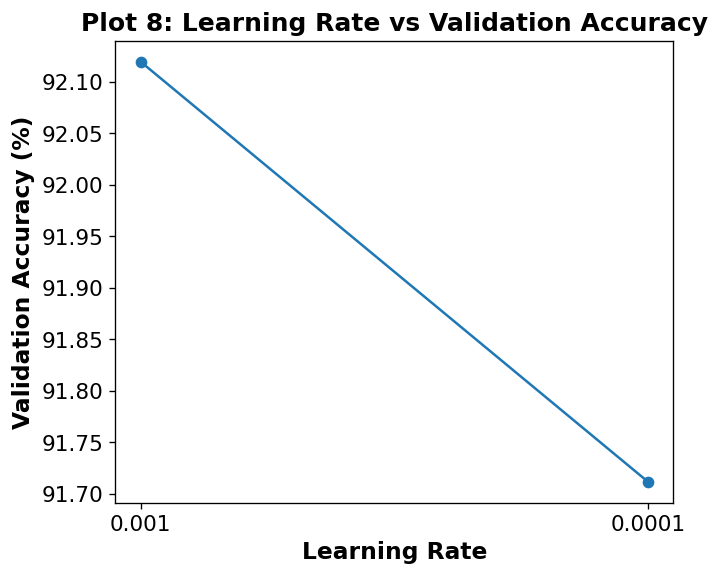

Saved: /content/plots/plot8_lr_vs_accuracy.png


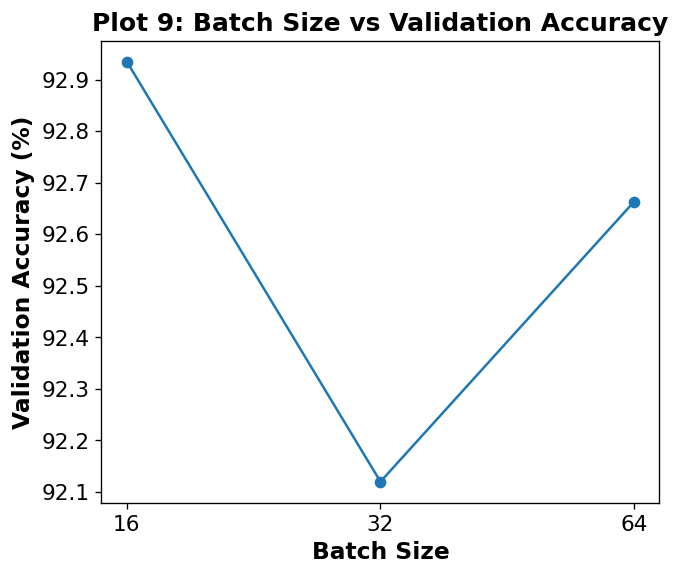

Saved: /content/plots/plot9_batchsize_vs_accuracy.png


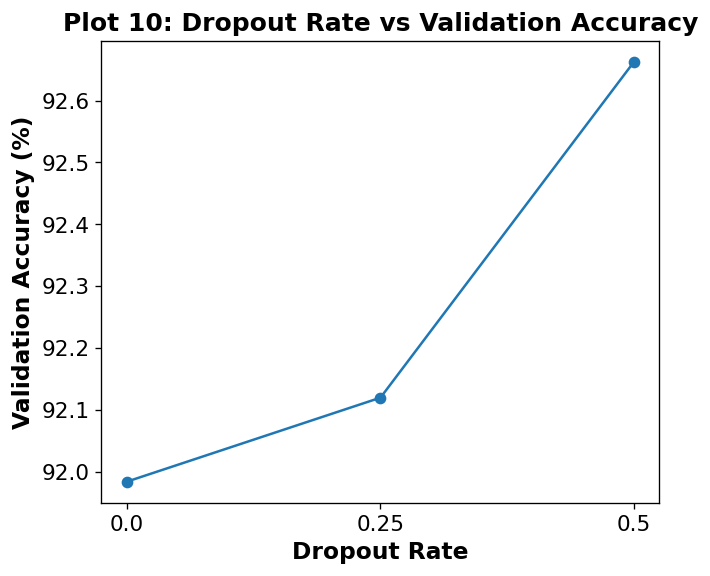

Saved: /content/plots/plot10_dropout_vs_accuracy.png


In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(list(map(str, lr_results.keys())), list(lr_results.values()), marker="o")
ax.set_xlabel("Learning Rate"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 8: Learning Rate vs Validation Accuracy")
save_and_show(fig, "plot8_lr_vs_accuracy")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(list(map(str, batch_results.keys())), list(batch_results.values()), marker="o")
ax.set_xlabel("Batch Size"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 9: Batch Size vs Validation Accuracy")
save_and_show(fig, "plot9_batchsize_vs_accuracy")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(list(map(str, dropout_results.keys())), list(dropout_results.values()), marker="o")
ax.set_xlabel("Dropout Rate"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 10: Dropout Rate vs Validation Accuracy")
save_and_show(fig, "plot10_dropout_vs_accuracy")

## 9. Section 10 — Transfer Learning vs Fine-Tuning (Plots 11 & 12)

**Case A (feature extraction)** reuses the cached-features approach — fast.
**Case B (fine-tuning)** unfreezes the last 30 layers of MobileNetV2 and trains on real images with a small learning rate (1e-5).

In [16]:
model_fe, hist_fe, t_fe = train_head(init_name="he", dropout_rate=0.25, use_bn=True,
                                      optimizer_name="adam", lr=0.001, epochs=20)
print(f"Case A (feature extraction) done in {t_fe:.1f}s")

Case A (feature extraction) done in 10.8s


In [17]:
def build_finetune_model(num_unfrozen=30, dropout_rate=0.25, num_classes=None):
    num_classes = num_classes or NUM_CLASSES
    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False,
                        weights="imagenet", pooling="avg")
    base.trainable = True
    for layer in base.layers[:-num_unfrozen]:
        layer.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.Dense(256, kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inputs, outputs)

print("Fine-tuning: unfreezing last 30 layers of MobileNetV2, lr=1e-5, 10 epochs.")
print("This trains through the backbone with real images -- expect ~15-25 min.")

set_seed()
ft_model = build_finetune_model(num_unfrozen=30, dropout_rate=0.25)
ft_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

train_batches = cached_dataset(train_paths, train_labels, "sec10_train", shuffle=True)
val_batches   = cached_dataset(val_paths, val_labels, "sec10_val")

t0 = time.time()
hist_ft = ft_model.fit(train_batches, validation_data=val_batches, epochs=10, verbose=1)
t_ft = time.time() - t0
print(f"Case B (fine-tuning) done in {t_ft/60:.1f} min")

clear_cache("sec10_train"); clear_cache("sec10_val")

Fine-tuning: unfreezing last 30 layers of MobileNetV2, lr=1e-5, 10 epochs.
This trains through the backbone with real images -- expect ~15-25 min.
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 62s 301ms/step - accuracy: 0.0639 - loss: 3.7652 - val_accuracy: 0.1291 - val_loss: 3.2882
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.2007 - loss: 3.0153 - val_accuracy: 0.3438 - val_loss: 2.6414
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.3798 - loss: 2.4359 - val_accuracy: 0.5448 - val_loss: 2.0905
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.5452 - loss: 1.9517 - val_accuracy: 0.6495 - val_loss: 1.6673
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.6658 - loss: 1.6047 - val_accuracy: 0.7188 - val_loss: 1.3597
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.7391 - loss: 1.3592 - val_accuracy: 0.7663 - val_loss: 1.1394
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.7918 - loss: 1.1515 -

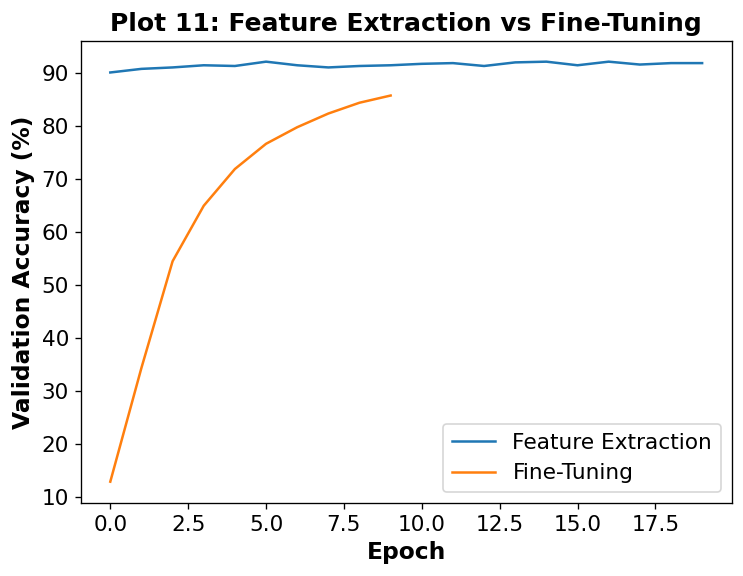

Saved: /content/plots/plot11_fe_vs_ft.png


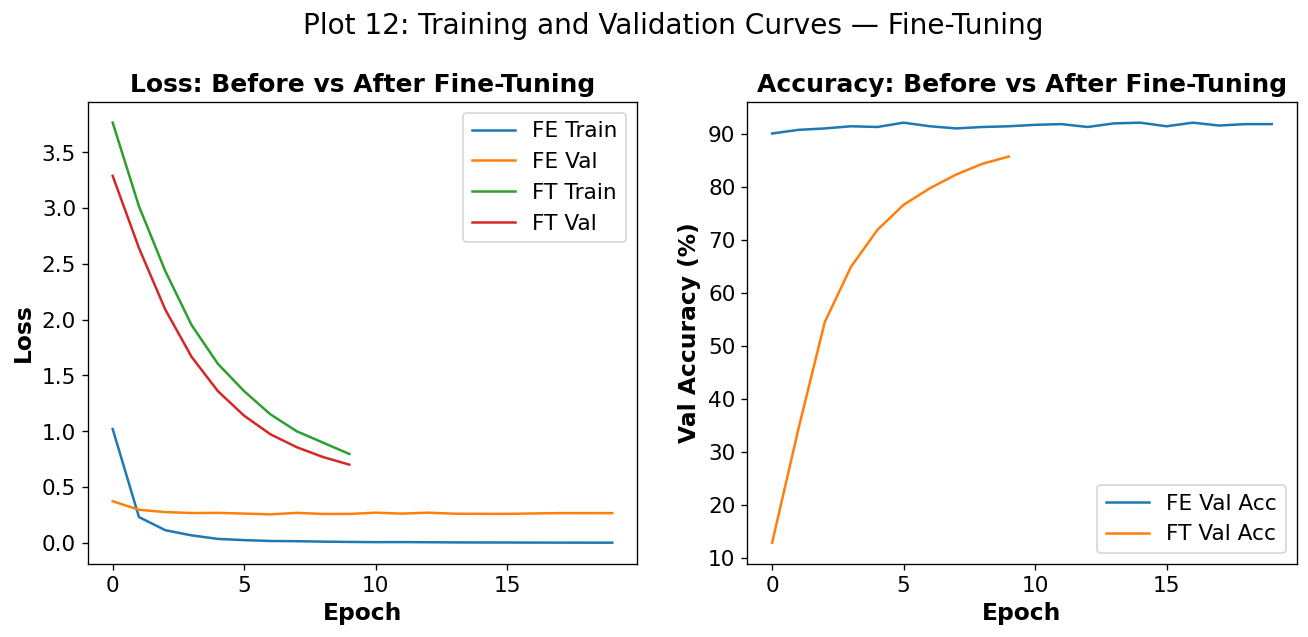

Saved: /content/plots/plot12_ft_loss_acc.png


In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([v*100 for v in hist_fe.history["val_accuracy"]], label="Feature Extraction")
ax.plot([v*100 for v in hist_ft.history["val_accuracy"]], label="Fine-Tuning")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Plot 11: Feature Extraction vs Fine-Tuning")
ax.legend()
save_and_show(fig, "plot11_fe_vs_ft")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(hist_fe.history["loss"], label="FE Train")
axes[0].plot(hist_fe.history["val_loss"], label="FE Val")
axes[0].plot(hist_ft.history["loss"], label="FT Train")
axes[0].plot(hist_ft.history["val_loss"], label="FT Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[0].set_title("Loss: Before vs After Fine-Tuning")

axes[1].plot([v*100 for v in hist_fe.history["val_accuracy"]], label="FE Val Acc")
axes[1].plot([v*100 for v in hist_ft.history["val_accuracy"]], label="FT Val Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Accuracy (%)"); axes[1].legend()
axes[1].set_title("Accuracy: Before vs After Fine-Tuning")
fig.suptitle("Plot 12: Training and Validation Curves — Fine-Tuning", y=1.03)
save_and_show(fig, "plot12_ft_loss_acc")

## 10. Section 11 — 5-Fold Cross-Validation (Plot 13)

4 configurations: 3 frozen-backbone (fast, cached features) + 1 fine-tuned (slow, real backbone gradients).

In [19]:
X_cv = np.concatenate([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

configs = {
    "C1_baseline":     dict(kind="frozen", init_name="random", dropout_rate=0.0,  use_bn=False, optimizer_name="sgd",   lr=0.001),
    "C2_best_reg":     dict(kind="frozen", init_name="he",     dropout_rate=0.25, use_bn=True,  optimizer_name="adam",  lr=0.001),
    "C3_best_hparam":  dict(kind="frozen", init_name="he",     dropout_rate=0.25, use_bn=True,  optimizer_name="adam",  lr=0.0001),
    "C4_finetuned":    dict(kind="finetune"),
}

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

In [20]:
# Frozen configs: fast, reuse cached features
for cfg_name, cfg in configs.items():
    if cfg["kind"] != "frozen":
        continue
    print(f"--- {cfg_name} (frozen, cached features) ---")
    fold_accs = []
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(X_cv)):
        set_seed()
        model = build_head(cfg["init_name"], cfg["dropout_rate"], cfg["use_bn"])
        model.compile(optimizer=get_optimizer(cfg["optimizer_name"], cfg["lr"]),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        model.fit(X_cv[tr_idx], y_cv[tr_idx], epochs=15, batch_size=32, verbose=0)
        _, acc = model.evaluate(X_cv[va_idx], y_cv[va_idx], verbose=0)
        fold_accs.append(acc)
        print(f"  Fold {fold_i+1}: val_acc={acc*100:.2f}%")
    cv_results[cfg_name] = fold_accs

--- C1_baseline (frozen, cached features) ---
  Fold 1: val_acc=67.93%
  Fold 2: val_acc=68.89%
  Fold 3: val_acc=68.61%
  Fold 4: val_acc=69.84%
  Fold 5: val_acc=68.48%
--- C2_best_reg (frozen, cached features) ---
  Fold 1: val_acc=90.49%
  Fold 2: val_acc=89.67%
  Fold 3: val_acc=91.44%
  Fold 4: val_acc=93.07%
  Fold 5: val_acc=91.17%
--- C3_best_hparam (frozen, cached features) ---
  Fold 1: val_acc=90.22%
  Fold 2: val_acc=89.40%
  Fold 3: val_acc=90.62%
  Fold 4: val_acc=93.34%
  Fold 5: val_acc=91.17%


In [21]:
# Fine-tuned config: builds fold datasets directly from file paths via tf.data --
# nothing materializes more than one batch (32 images, ~19MB) in memory at a time,
# so this doesn't risk the OOM crash that a full np.stack() of ~4,600 images would.
all_ft_paths = np.array(train_paths + val_paths)
all_ft_labels = np.array(train_labels + val_labels)

print("--- C4_finetuned (real backbone gradients, slowest section) ---")
fold_accs = []
for fold_i, (tr_idx, va_idx) in enumerate(kf.split(all_ft_paths)):
    set_seed()
    m = build_finetune_model(num_unfrozen=30, dropout_rate=0.25)
    m.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    train_ds_fold = cached_dataset(all_ft_paths[tr_idx].tolist(), all_ft_labels[tr_idx].tolist(),
                                    f"sec11_fold{fold_i}_train", shuffle=True)
    val_ds_fold = cached_dataset(all_ft_paths[va_idx].tolist(), all_ft_labels[va_idx].tolist(),
                                  f"sec11_fold{fold_i}_val")

    m.fit(train_ds_fold, epochs=5, verbose=0)
    _, acc = m.evaluate(val_ds_fold, verbose=0)
    fold_accs.append(acc)
    print(f"  Fold {fold_i+1}: val_acc={acc*100:.2f}%")

    # Disk cache per fold covers a different image subset each time -- clear it before
    # the next fold so the cache directory doesn't grow across all 5 folds.
    clear_cache(f"sec11_fold{fold_i}_train"); clear_cache(f"sec11_fold{fold_i}_val")
cv_results["C4_finetuned"] = fold_accs


--- C4_finetuned (real backbone gradients, slowest section) ---
  Fold 1: val_acc=72.42%
  Fold 2: val_acc=73.91%
  Fold 3: val_acc=72.28%
  Fold 4: val_acc=76.09%
  Fold 5: val_acc=71.33%


                      F1        F2        F3        F4        F5      Mean  \
C1_baseline     0.679348  0.688859  0.686141  0.698370  0.684783  0.687500   
C2_best_reg     0.904891  0.896739  0.914402  0.930707  0.911685  0.911685   
C3_best_hparam  0.902174  0.894022  0.906250  0.933424  0.911685  0.909511   
C4_finetuned    0.724185  0.739130  0.722826  0.760870  0.713315  0.732065   

                      SD  
C1_baseline     0.006994  
C2_best_reg     0.012637  
C3_best_hparam  0.014840  
C4_finetuned    0.018565  


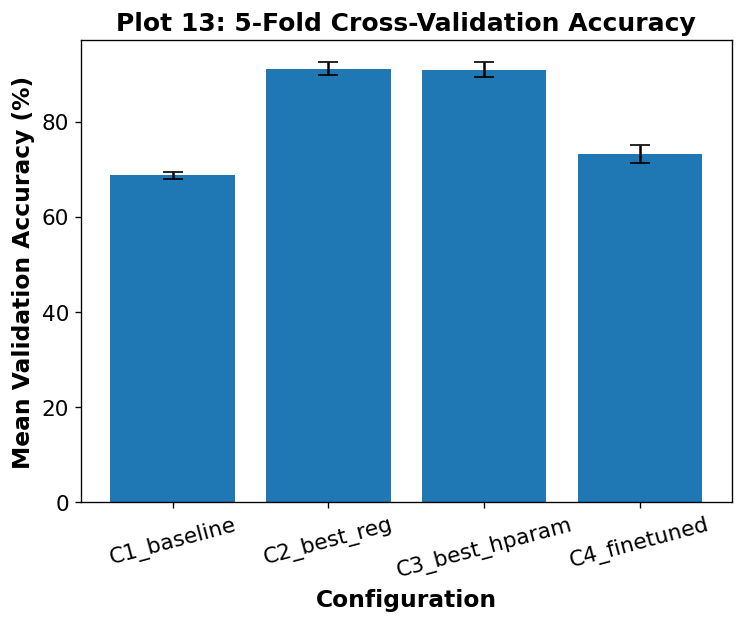

Saved: /content/plots/plot13_cv_accuracy.png


In [22]:
cv_summary = pd.DataFrame(cv_results).T
cv_summary.columns = [f"F{i+1}" for i in range(5)]
cv_summary["Mean"] = cv_summary.iloc[:, :5].mean(axis=1)
cv_summary["SD"] = cv_summary.iloc[:, :5].std(axis=1)
print(cv_summary)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(cv_summary.index, cv_summary["Mean"] * 100, yerr=cv_summary["SD"] * 100, capsize=6)
ax.set_xlabel("Configuration"); ax.set_ylabel("Mean Validation Accuracy (%)")
ax.set_title("Plot 13: 5-Fold Cross-Validation Accuracy")
plt.xticks(rotation=15)
save_and_show(fig, "plot13_cv_accuracy")

## 11. Section 12 — Final Model Evaluation (Plot 14, optional Plot 15)
Selects the best config by mean CV accuracy, retrains on the full train+val pool, evaluates once on the untouched test set.

In [23]:
best_cfg_name = cv_summary["Mean"].idxmax()
print(f"Best configuration by mean CV accuracy: {best_cfg_name}")
best_cfg = configs[best_cfg_name]

Best configuration by mean CV accuracy: C2_best_reg


In [24]:
if best_cfg["kind"] == "frozen":
    set_seed()
    final_model = build_head(best_cfg["init_name"], best_cfg["dropout_rate"], best_cfg["use_bn"])
    final_model.compile(optimizer=get_optimizer(best_cfg["optimizer_name"], best_cfg["lr"]),
                         loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    final_model.fit(X_cv, y_cv, epochs=25, batch_size=32, verbose=1)
    train_time = time.time() - t0
    y_pred = np.argmax(final_model.predict(X_test), axis=1)
    y_true = y_test
    n_params = final_model.count_params()
else:
    print("Best config is the fine-tuned model — retraining on full images, expect ~20-30 min.")
    set_seed()
    final_model = build_finetune_model(num_unfrozen=30, dropout_rate=0.25)
    final_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                         loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    full_train_ds = cached_dataset(train_paths + val_paths, train_labels + val_labels,
                                    "sec12_final_train", shuffle=True)

    t0 = time.time()
    final_model.fit(full_train_ds, epochs=10, verbose=1)
    train_time = time.time() - t0
    clear_cache("sec12_final_train")

    # Test set is only predicted on once here -- no benefit to caching a single pass.
    test_ds_batched = ds_test.batch(32).prefetch(tf.data.AUTOTUNE)
    y_pred = np.argmax(final_model.predict(test_ds_batched), axis=1)
    y_true = np.array(test_labels)  # already parsed from annotations, same order as ds_test
    n_params = final_model.count_params()

test_acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Precision (macro): {precision:.4f} | Recall (macro): {recall:.4f} | F1 (macro): {f1:.4f}")
print(f"Training Time: {train_time:.1f}s | Parameters: {n_params:,}")


# Preserve the selected configuration's own numbers before Section 13 reuses similar
# variable names in its own loop -- avoids a silent overwrite bug.
selected_config_name = best_cfg_name
selected_config_test_acc = test_acc
selected_config_train_time = train_time


Epoch 1/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7690 - loss: 0.8933
Epoch 2/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9421 - loss: 0.2185
Epoch 3/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9799 - loss: 0.1033
Epoch 4/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9967 - loss: 0.0512
Epoch 5/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0308
Epoch 6/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9989 - loss: 0.0249
Epoch 7/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9995 - loss: 0.0169
Epoch 8/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9995 - loss: 0.0137
Epoch 9/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0085
Epoch 10/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0069
Epoch 11/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0060
Epoch 12/25
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

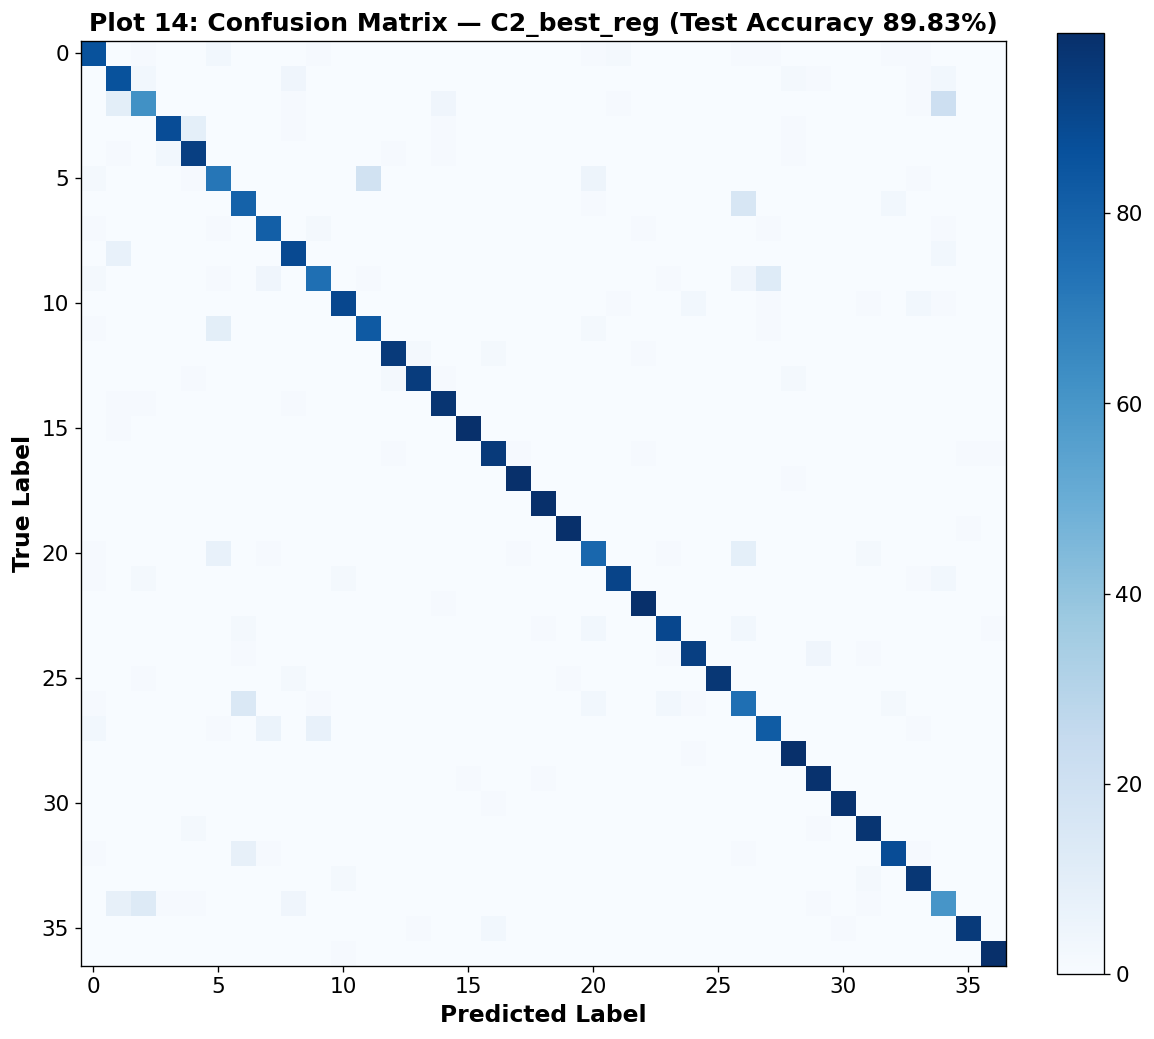

Saved: /content/plots/plot14_confusion_matrix.png
Top confused breed pairs (true -> predicted, count):
  american_pit_bull_terrier -> staffordshire_bull_terrier : 21
  Bengal                    -> Egyptian_Mau              : 19
  Birman                    -> Ragdoll                   : 16
  Ragdoll                   -> Birman                    : 14
  staffordshire_bull_terrier -> american_pit_bull_terrier : 13
  British_Shorthair         -> Russian_Blue              : 12
  american_pit_bull_terrier -> american_bulldog          : 10
  Egyptian_Mau              -> Bengal                    : 10
  basset_hound              -> beagle                    : 9
  Maine_Coon                -> Ragdoll                   : 9


In [25]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(11, 11))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
ax.set_title(f"Plot 14: Confusion Matrix — {best_cfg_name} (Test Accuracy {test_acc*100:.2f}%)")
fig.colorbar(im, ax=ax, fraction=0.046)
save_and_show(fig, "plot14_confusion_matrix")

# Most-confused class pairs, useful for the required discussion
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
top_confusions = np.dstack(np.unravel_index(np.argsort(-cm_off_diag.ravel())[:10], cm_off_diag.shape))[0]
print("Top confused breed pairs (true -> predicted, count):")
for i, j in top_confusions:
    if cm_off_diag[i, j] > 0:
        print(f"  {label_names[i]:25s} -> {label_names[j]:25s} : {cm_off_diag[i, j]}")

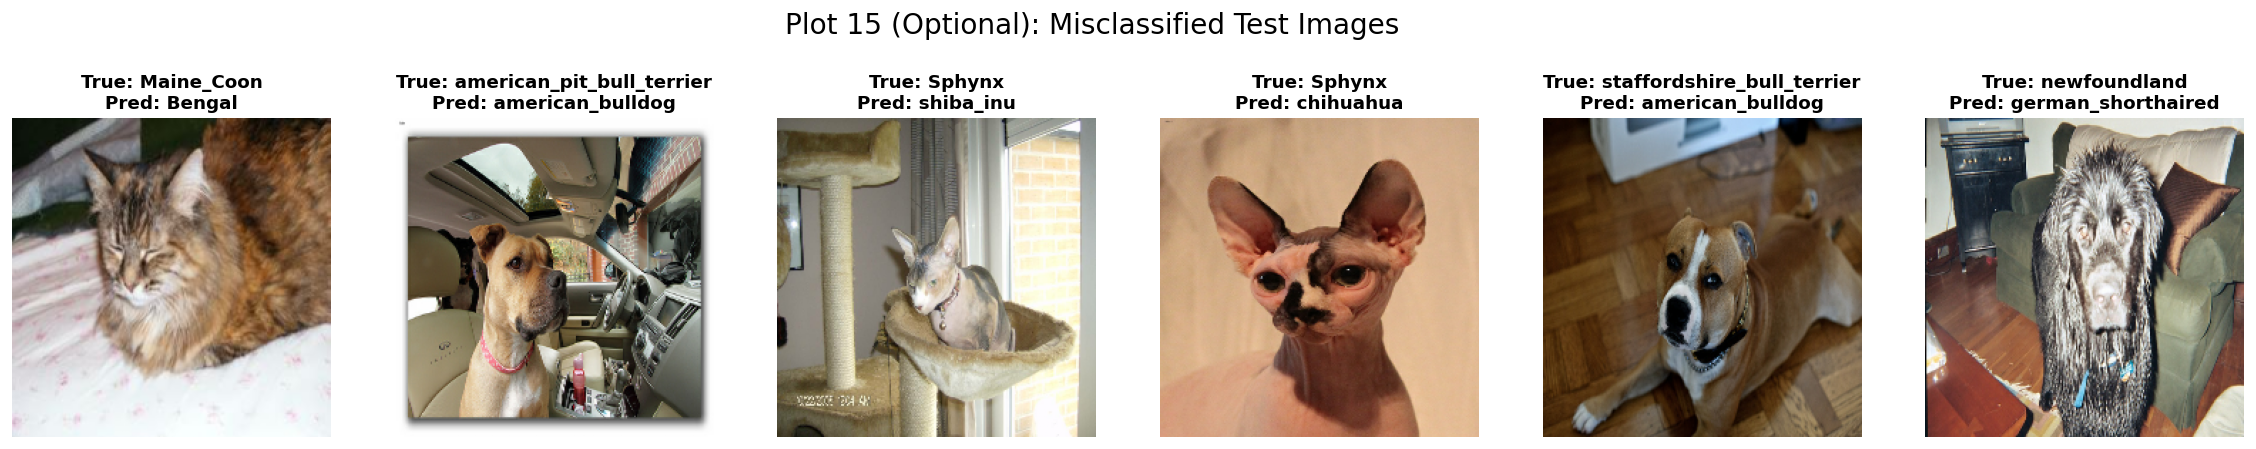

Saved: /content/plots/plot15_misclassified_examples.png


In [26]:
# Optional Plot 15: a handful of misclassified images for the report.
# Decodes only the sampled images directly from disk -- not the whole test set --
# to avoid materializing thousands of images in memory just to display six.
wrong_idx = np.where(y_pred != y_true)[0]
sample_idx = np.random.choice(wrong_idx, size=min(6, len(wrong_idx)), replace=False)

def unnormalize(img):
    img = (img + 1.0) / 2.0  # undo preprocess_input's scaling to [-1, 1]
    return np.clip(img, 0, 1)

def load_raw_image(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img.numpy()

fig, axes = plt.subplots(1, len(sample_idx), figsize=(4*len(sample_idx), 4))
for ax, idx in zip(axes, sample_idx):
    img = load_raw_image(test_paths[idx])
    ax.imshow(unnormalize(img))
    ax.set_title(f"True: {label_names[y_true[idx]]}\nPred: {label_names[y_pred[idx]]}", fontsize=11)
    ax.axis("off")
fig.suptitle("Plot 15 (Optional): Misclassified Test Images", y=1.05)
save_and_show(fig, "plot15_misclassified_examples")


## 12. Save everything: zip all plots for download
Run this even if you plan to keep working — it snapshots what you have so a disconnect doesn't cost you the plots.

In [27]:
zip_path = "/content/CS3807_Exp5_plots.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for fname in sorted(os.listdir(PLOT_DIR)):
        zf.write(os.path.join(PLOT_DIR, fname), arcname=fname)
print(f"Zipped {len(os.listdir(PLOT_DIR))} plots to {zip_path}")

from google.colab import files
files.download(zip_path)

Zipped 15 plots to /content/CS3807_Exp5_plots.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Overall Results (Section 13 according to Manual)


In [28]:
overall_configs = {
    "Baseline": dict(kind="frozen", init_name="random", dropout_rate=0.0, use_bn=False,
                      l2_lambda=0.0, optimizer_name="sgd", lr=0.001, batch_size=32),
    "Best Initialization": dict(kind="frozen", init_name="he", dropout_rate=0.0, use_bn=False,
                                 l2_lambda=0.0, optimizer_name="sgd", lr=0.001, batch_size=32),
    "Best Regularization": dict(kind="frozen", init_name="random", dropout_rate=0.0, use_bn=False,
                                 l2_lambda=0.001, optimizer_name="sgd", lr=0.001, batch_size=32),
    "Best Optimizer": dict(kind="frozen", init_name="random", dropout_rate=0.0, use_bn=False,
                            l2_lambda=0.0, optimizer_name="rmsprop", lr=0.001, batch_size=32),
    "Best Hyperparameters": dict(kind="frozen", init_name="he", dropout_rate=0.5, use_bn=True,
                                  l2_lambda=0.0, optimizer_name="adam", lr=0.001, batch_size=16),
    "Fine-Tuned Model": dict(kind="finetune"),
}

overall_rows = []

for name, cfg in overall_configs.items():
    print(f"--- {name} ---")
    if cfg["kind"] == "frozen":
        fold_accs = []
        for fold_i, (tr_idx, va_idx) in enumerate(kf.split(X_cv)):
            set_seed()
            m = build_head(cfg["init_name"], cfg["dropout_rate"], cfg["use_bn"], cfg["l2_lambda"])
            m.compile(optimizer=get_optimizer(cfg["optimizer_name"], cfg["lr"]),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
            m.fit(X_cv[tr_idx], y_cv[tr_idx], epochs=15, batch_size=cfg["batch_size"], verbose=0)
            _, acc = m.evaluate(X_cv[va_idx], y_cv[va_idx], verbose=0)
            fold_accs.append(acc)
        cfg_cv_mean, cfg_cv_sd = float(np.mean(fold_accs)), float(np.std(fold_accs))

        set_seed()
        final_m = build_head(cfg["init_name"], cfg["dropout_rate"], cfg["use_bn"], cfg["l2_lambda"])
        final_m.compile(optimizer=get_optimizer(cfg["optimizer_name"], cfg["lr"]),
                         loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        t0 = time.time()
        final_m.fit(X_cv, y_cv, epochs=25, batch_size=cfg["batch_size"], verbose=0)
        cfg_train_time = time.time() - t0
        _, cfg_test_acc = final_m.evaluate(X_test, y_test, verbose=0)

    else:  # fine-tuned
        cfg_cv_mean = float(cv_summary.loc["C4_finetuned", "Mean"])
        cfg_cv_sd = float(cv_summary.loc["C4_finetuned", "SD"])

        print("  Retraining fine-tuned model on full data for its own test evaluation (~15-25 min)...")
        set_seed()
        final_m = build_finetune_model(num_unfrozen=30, dropout_rate=0.25)
        final_m.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                         loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        full_ds = cached_dataset(train_paths + val_paths, train_labels + val_labels,
                                  "sec13_ft_train", shuffle=True)
        t0 = time.time()
        final_m.fit(full_ds, epochs=10, verbose=0)
        cfg_train_time = time.time() - t0
        clear_cache("sec13_ft_train")

        test_ds_b = ds_test.batch(32).prefetch(tf.data.AUTOTUNE)
        _, cfg_test_acc = final_m.evaluate(test_ds_b, verbose=0)

    overall_rows.append({
        "Configuration": name,
        "CV Accuracy": f"{cfg_cv_mean*100:.2f}%",
        "SD": f"{cfg_cv_sd*100:.2f}%",
        "Test Accuracy": f"{cfg_test_acc*100:.2f}%",
        "Training Time (s)": round(cfg_train_time, 1),
    })
    print(f"  CV: {cfg_cv_mean*100:.2f}% +/- {cfg_cv_sd*100:.2f}% | "
          f"Test: {cfg_test_acc*100:.2f}% | Time: {cfg_train_time:.1f}s")

overall_results_table = pd.DataFrame(overall_rows)
print("\nNote for the report: Section 6's sweep found NO regularization (92.80%) beat every")
print("regularization technique actually tested -- worth stating directly rather than letting")
print("the \"Best Regularization\" label imply regularization helped here.")
print("\nSection 13 -- Overall Results:")
overall_results_table


--- Baseline ---
  CV: 68.75% +/- 0.63% | Test: 84.14% | Time: 9.4s
--- Best Initialization ---
  CV: 78.51% +/- 1.75% | Test: 85.72% | Time: 10.8s
--- Best Regularization ---
  CV: 68.72% +/- 0.66% | Test: 84.14% | Time: 9.6s
--- Best Optimizer ---
  CV: 91.06% +/- 1.12% | Test: 89.89% | Time: 9.6s
--- Best Hyperparameters ---
  CV: 91.36% +/- 0.91% | Test: 88.88% | Time: 19.5s
--- Fine-Tuned Model ---
  Retraining fine-tuned model on full data for its own test evaluation (~15-25 min)...
  CV: 73.21% +/- 1.86% | Test: 86.67% | Time: 113.8s

Note for the report: Section 6's sweep found NO regularization (92.80%) beat every
regularization technique actually tested -- worth stating directly rather than letting
the "Best Regularization" label imply regularization helped here.

Section 13 -- Overall Results:


,Configuration,CV Accuracy,SD,Test Accuracy,Training Time (s)
0,Baseline,68.75%,0.63%,84.14%,9.4
1,Best Initialization,78.51%,1.75%,85.72%,10.8
2,Best Regularization,68.72%,0.66%,84.14%,9.6
3,Best Optimizer,91.06%,1.12%,89.89%,9.6
4,Best Hyperparameters,91.36%,0.91%,88.88%,19.5
5,Fine-Tuned Model,73.21%,1.86%,86.67%,113.8


## 14. Section 16 — Additional Exercise

Two new combinations varying learning rate, dropout, batch size, **and fine-tuning
strategy**, evaluated via 5-fold CV and
compared against the selected configuration from Section 11/12.

- **New Combo 1:** frozen-head (feature-extraction strategy), lr=0.0005, dropout=0.4, batch=24 — fast, cached features.
- **New Combo 2:** fine-tuned with only the **last 15** layers unfrozen (vs. 30 in Sections 10/11 — a more conservative fine-tuning strategy), lr=5e-6, dropout=0.3, batch=24 — real backbone gradients across 5 folds, **expect ~45-75 min**, then another ~15-20 min to retrain on full data for its test score.

In [29]:
# --- New Combo 1: frozen head ---
combo1_cfg = dict(init_name="he", dropout_rate=0.4, use_bn=True, l2_lambda=0.0,
                   optimizer_name="adam", lr=0.0005, batch_size=24)

print("--- New Combo 1 (frozen head) ---")
fold_accs = []
for fold_i, (tr_idx, va_idx) in enumerate(kf.split(X_cv)):
    set_seed()
    m = build_head(combo1_cfg["init_name"], combo1_cfg["dropout_rate"], combo1_cfg["use_bn"], combo1_cfg["l2_lambda"])
    m.compile(optimizer=get_optimizer(combo1_cfg["optimizer_name"], combo1_cfg["lr"]),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    m.fit(X_cv[tr_idx], y_cv[tr_idx], epochs=15, batch_size=combo1_cfg["batch_size"], verbose=0)
    _, acc = m.evaluate(X_cv[va_idx], y_cv[va_idx], verbose=0)
    fold_accs.append(acc)
c1_cv_mean, c1_cv_sd = float(np.mean(fold_accs)), float(np.std(fold_accs))

set_seed()
final_c1 = build_head(combo1_cfg["init_name"], combo1_cfg["dropout_rate"], combo1_cfg["use_bn"], combo1_cfg["l2_lambda"])
final_c1.compile(optimizer=get_optimizer(combo1_cfg["optimizer_name"], combo1_cfg["lr"]),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.time()
final_c1.fit(X_cv, y_cv, epochs=25, batch_size=combo1_cfg["batch_size"], verbose=0)
c1_time = time.time() - t0
_, c1_test_acc = final_c1.evaluate(X_test, y_test, verbose=0)

print(f"  CV: {c1_cv_mean*100:.2f}% +/- {c1_cv_sd*100:.2f}% | Test: {c1_test_acc*100:.2f}% | Time: {c1_time:.1f}s")


--- New Combo 1 (frozen head) ---
  CV: 91.28% +/- 1.28% | Test: 89.34% | Time: 15.7s


In [30]:
# --- New Combo 2: fine-tuned, 15 unfrozen layers (more conservative than Sections 10/11's 30) ---
combo2_cfg = dict(num_unfrozen=15, dropout_rate=0.3, lr=5e-6, batch_size=24)

print("--- New Combo 2 (fine-tuned, 15 unfrozen layers) ---")
print("Real backbone gradients across 5 folds -- expect ~45-75 min.")

fold_accs2 = []
for fold_i, (tr_idx, va_idx) in enumerate(kf.split(all_ft_paths)):
    set_seed()
    m2 = build_finetune_model(num_unfrozen=combo2_cfg["num_unfrozen"], dropout_rate=combo2_cfg["dropout_rate"])
    m2.compile(optimizer=optimizers.Adam(learning_rate=combo2_cfg["lr"]),
               loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    train_ds_fold2 = cached_dataset(all_ft_paths[tr_idx].tolist(), all_ft_labels[tr_idx].tolist(),
                                     f"sec16_fold{fold_i}_train", batch_size=combo2_cfg["batch_size"], shuffle=True)
    val_ds_fold2 = cached_dataset(all_ft_paths[va_idx].tolist(), all_ft_labels[va_idx].tolist(),
                                   f"sec16_fold{fold_i}_val", batch_size=combo2_cfg["batch_size"])
    m2.fit(train_ds_fold2, epochs=5, verbose=0)
    _, acc2 = m2.evaluate(val_ds_fold2, verbose=0)
    fold_accs2.append(acc2)
    print(f"  Fold {fold_i+1}: val_acc={acc2*100:.2f}%")
    clear_cache(f"sec16_fold{fold_i}_train"); clear_cache(f"sec16_fold{fold_i}_val")

c2_cv_mean, c2_cv_sd = float(np.mean(fold_accs2)), float(np.std(fold_accs2))

print("Retraining Combo 2 on full data for test evaluation (~15-20 min)...")
set_seed()
final_c2 = build_finetune_model(num_unfrozen=combo2_cfg["num_unfrozen"], dropout_rate=combo2_cfg["dropout_rate"])
final_c2.compile(optimizer=optimizers.Adam(learning_rate=combo2_cfg["lr"]),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
full_ds2 = cached_dataset(train_paths + val_paths, train_labels + val_labels, "sec16_combo2_train",
                           batch_size=combo2_cfg["batch_size"], shuffle=True)
t0 = time.time()
final_c2.fit(full_ds2, epochs=10, verbose=0)
c2_time = time.time() - t0
clear_cache("sec16_combo2_train")

test_ds_b2 = ds_test.batch(combo2_cfg["batch_size"]).prefetch(tf.data.AUTOTUNE)
_, c2_test_acc = final_c2.evaluate(test_ds_b2, verbose=0)

print(f"  CV: {c2_cv_mean*100:.2f}% +/- {c2_cv_sd*100:.2f}% | Test: {c2_test_acc*100:.2f}% | Time: {c2_time:.1f}s")


--- New Combo 2 (fine-tuned, 15 unfrozen layers) ---
Real backbone gradients across 5 folds -- expect ~45-75 min.
  Fold 1: val_acc=54.21%
  Fold 2: val_acc=55.84%
  Fold 3: val_acc=56.25%
  Fold 4: val_acc=55.43%
  Fold 5: val_acc=52.72%
Retraining Combo 2 on full data for test evaluation (~15-20 min)...
  CV: 54.89% +/- 1.28% | Test: 81.68% | Time: 202.2s


In [31]:
additional_rows = [
    {
        "Configuration": "New Combo 1 (frozen, lr=5e-4, dropout=0.4, batch=24)",
        "CV Accuracy": f"{c1_cv_mean*100:.2f}%", "SD": f"{c1_cv_sd*100:.2f}%",
        "Test Accuracy": f"{c1_test_acc*100:.2f}%", "Training Time (s)": round(c1_time, 1),
    },
    {
        "Configuration": "New Combo 2 (fine-tuned, 15 layers, lr=5e-6, dropout=0.3, batch=24)",
        "CV Accuracy": f"{c2_cv_mean*100:.2f}%", "SD": f"{c2_cv_sd*100:.2f}%",
        "Test Accuracy": f"{c2_test_acc*100:.2f}%", "Training Time (s)": round(c2_time, 1),
    },
    {
        "Configuration": f"Selected Configuration ({selected_config_name})",
        "CV Accuracy": f"{cv_summary.loc[selected_config_name, 'Mean']*100:.2f}%",
        "SD": f"{cv_summary.loc[selected_config_name, 'SD']*100:.2f}%",
        "Test Accuracy": f"{selected_config_test_acc*100:.2f}%",
        "Training Time (s)": round(selected_config_train_time, 1),
    },
]

additional_comparison_table = pd.DataFrame(additional_rows)
print("Section 16 -- Additional Exercise: Comparison")
additional_comparison_table


Section 16 -- Additional Exercise: Comparison


,Configuration,CV Accuracy,SD,Test Accuracy,Training Time (s)
0,"New Combo 1 (frozen, lr=5e-4, dropout=0.4, bat...",91.28%,1.28%,89.34%,15.7
1,"New Combo 2 (fine-tuned, 15 layers, lr=5e-6, d...",54.89%,1.28%,81.68%,202.2
2,Selected Configuration (C2_best_reg),91.17%,1.26%,89.83%,12.4
